In [1]:
import qiskit as qk
import numpy as np
import qiskit_aer
from qiskit.circuit.library import QFT, ZGate, GlobalPhaseGate
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=5)


In [2]:
def lcg(bits: int, m: int, c: int, x: int, n: int) -> int:
    """
    n steps of Linear congruential generator with parameters m and c
    """
    m_n = pow(m, n, mod=(m-1) * 2**bits)
    return (m_n * x + c * (m_n - 1) // (m - 1)) % (2 ** bits)

def cyclic_rshift(x, n, bits):
    return x >> n | ((x << (bits - n)) & (2 ** bits - 1))

def pcg(m: int, c: int, x: int, n: int) -> int:
    x = lcg(6, m, c, x, n)

    # XOR shift
    x = x ^ (x >> 2)

    x, y = x % (2 ** 4), x // (2 ** 4)
    x = cyclic_rshift(x, y, 4)
    
    return x

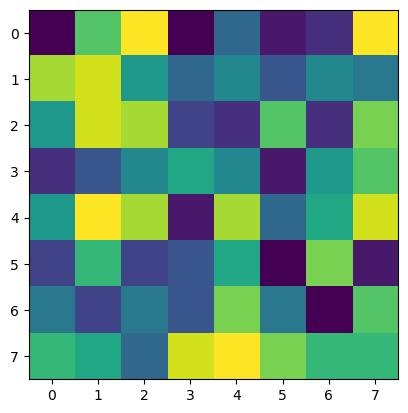

In [3]:
m = 17
c = 9
x0 = 42

results = np.array([pcg(m, c, x0, n) for n in range(2**6)])

plt.imshow(results.reshape((8, 8)))
plt.show()

In [4]:
def constant_add(bits: int, m: int, control_bits=1) -> qk.QuantumCircuit:
    """
    Circuit for adding a constant to a register of `bits` qubits

    If control_bits is not zero, this returns a controlled gate.
    """
    if control_bits == 0:
        x = qk.QuantumRegister(bits, name="x")
        qc = qk.QuantumCircuit(x, name="+" + str(m))
    elif control_bits == 1:
        c = qk.QuantumRegister(1, name="c")
        x = qk.QuantumRegister(bits, name="x")
        qc = qk.QuantumCircuit(c, x, name="+" + str(m))
    else:
        c = qk.QuantumRegister(control_bits, name="c")
        x = qk.QuantumRegister(bits, name="x")
        a = qk.QuantumRegister(1, name="a")
        qc = qk.QuantumCircuit(c, x, a, name="+" + str(m))

    phases = np.zeros(bits)

    for k in range(bits):
        for j in range(k + 1):
            if (m >> j) & 1 == 1:
                phases[k] += 2**j

    ctrl = None
    if control_bits == 1:
        ctrl = c
    elif control_bits > 0:
        qc.mcx(c, a)
        ctrl = a
    for k in range(bits):
        if phases[k] == 0:
            continue
        if ctrl is None:
            qc.p(phases[k] * np.pi / 2**k, x[k])
        else:
            qc.mcp(phases[k] * np.pi / 2**k, ctrl, x[k])
    if control_bits > 1:
        qc.mcx(c, a)

    return qc


def constant_mult(bits: int, m: int) -> qk.QuantumCircuit:
    """
    Circuit for multiplying an odd constant to a register of `bits` qubits
    """
    assert m % 2 == 1

    # Assumes that the high `bits - 1` bits of x encode the Fourier transform of
    # the actual bits.

    c = qk.QuantumRegister(1, name="c")
    x = qk.QuantumRegister(bits, name="x")
    a = qk.QuantumRegister(1, name="a")

    qc = qk.QuantumCircuit(c, x, a, name=f"*{m}")

    qc.h(x[-1])
    for i in reversed(range(bits - 1)):
        qc.compose(
            constant_add(bits - i - 1, m >> 1, control_bits=2),
            c[:] + [x[i]] + x[i + 1 :] + a[:],
            inplace=True
        )

        for k in range(1, bits - i):
            qc.cp(2 * np.pi / 2 ** (k + 1), x[i + k], x[i])
        qc.h(x[i])

    return qc
    
def mod_inv(n, bits):
    """
    Modular inverse of n with respect to the modulus 2**m
    """
    return pow(n, -1, mod=2**bits)

def circuit_lcg(bits: int, bits_step: int, m: int, c: int) -> qk.QuantumCircuit:
    """
    Circuit that implement skipping for a linear congruential generator (LCG)

    m and c correspond to the parameters of the lcg, then calculations are
    preformed modulo 2**bits, and bits_step determines the number of bits for
    the size of the skip.
    """
    n = qk.QuantumRegister(bits_step, name="n")
    x = qk.QuantumRegister(bits, name="x")
    a = qk.QuantumRegister(1, name="a")

    qc = qk.QuantumCircuit(n, x, a, name="lcg")

    acc = m
    acc_c = c
    for i in range(bits_step):
        if i % 2 == 0:
            qc.compose(constant_mult(bits, acc), [n[i]] + x[:] + a[:], inplace=True)
            qc.compose(constant_add(bits, acc_c), [n[i]] + x[:], inplace=True)
        else:
            factor = mod_inv(acc, bits)
            shift = (acc_c * factor) % (2**bits)
            qc.compose(constant_add(bits, shift), [n[i]] + x[:], inplace=True)
            qc.compose(constant_mult(bits, factor).inverse(), [n[i]] + x[:] + a[:], inplace=True)
        acc_c = (acc_c + acc * acc_c) % (2**bits)
        acc = (acc**2) % (2**bits)

    if bits_step % 2 == 1:
        qc.append(QFT(bits, do_swaps=False).inverse(), x[:])

    return qc

def CInc(N):
    """
    Circuit implementing a increment operation of the second N-qubit register
    controlled by the first quibt register.

    Optimized variants are implemented for N = 1, 2
    """
    x = qk.QuantumRegister(1, name="x")
    y = qk.QuantumRegister(N, name="y")

    qc = qk.QuantumCircuit(x, y, name="c_inc")

    if N == 1:
        qc.cx(x, y)
    elif N == 2:
        qc.ccx(x, y[0], y[1])
        qc.cx(x, y[0])
    else:
        qc.append(QFT(N, do_swaps=False).to_gate(), y[:])
        for j in range(N):
            lam = np.pi / (2**j)
            qc.cp(lam, x, y[j])
        qc.append(QFT(N, do_swaps=False).inverse().to_gate(), y[:])

    return qc


def CRShift(LOG_N, uncompute_control=False):
    """
    Circuit implementing a bitwise right shift of the first register by the
    second register.

    The first register is interpreted as consisting of DIM registers with N
    qubits each, all of which are shifted.
    """

    N = 2**LOG_N
    x = qk.QuantumRegister(N, name="x")
    y = qk.QuantumRegister(LOG_N, name="y")

    qc = qk.QuantumCircuit(x, y, name="shift")
    
    if LOG_N == 1:
        qc.cswap(y[0], x[0], x[1])
    else:
        for i in range(0, N, 2):
            qc.cswap(y[0], x[i], x[i + 1])
        next = CRShift(LOG_N - 1)
        qc.compose(next, x[::2] + y[1:], inplace=True)
        qc.compose(CInc(LOG_N - 1), y[:], inplace=True)
    
        qc.compose(next, x[1::2] + y[1:], inplace=True)
        if uncompute_control:
            qc.compose(CInc(LOG_N - 1).inverse(), y[:], inplace=True)

    return qc



def xorshift(bits: int, shift: int) -> qk.QuantumCircuit:
    """
    Circuit that xors the highest (bits - shift) bits onto the lowest
    (bits - shift) bits
    """
    assert shift < bits

    qc = qk.QuantumCircuit(bits, name=f"xs({shift})")

    for i in range(bits - shift):
        qc.cx(i + shift, i)

    return qc

In [5]:
def circuit_pcg(m, c) -> qk.QuantumCircuit:
    """
    Implementation of a permuted congruential generator (PCG) with state size 6
    and which outputs a 4 bit random integer.
    """
    n = qk.QuantumRegister(6, name="n")
    x = qk.QuantumRegister(6, name="x")
    a = qk.QuantumRegister(1, name="a")

    circ = qk.QuantumCircuit(n, x, a, name="pcg")
    circ.append(circuit_lcg(6, 6, m, c).to_gate(), n[:] + x[:] + a[:])
    circ.append(xorshift(6, 2).to_gate(), x[:])
    circ.append(CRShift(2).to_gate(), x[:4] + x[-2:])

    return circ
    

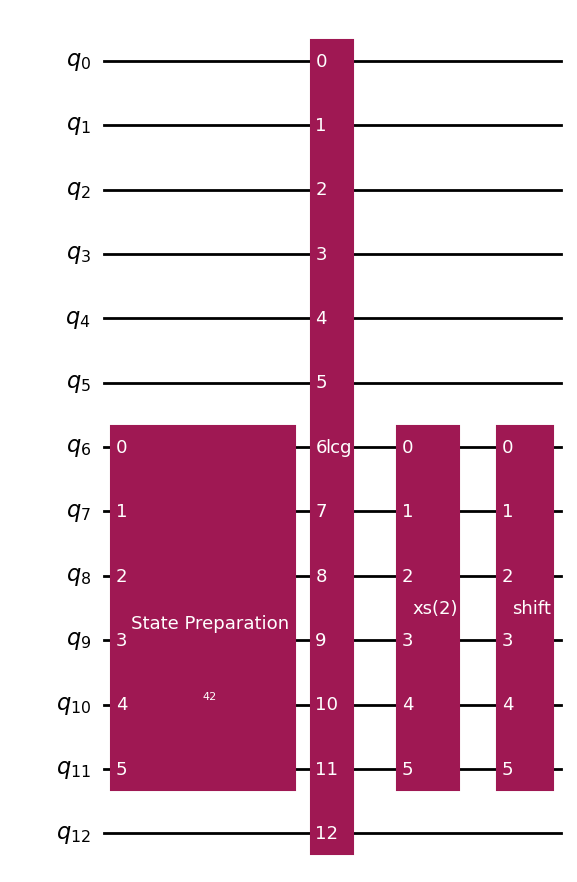

In [6]:
qc_pcg = qk.QuantumCircuit(13, name="pcg")
qc_pcg.prepare_state(x0, list(range(6, 12)))
qc_pcg.compose(circuit_pcg(m, c), list(range(0, 13)), inplace=True)
qc_pcg.draw(output="mpl")

In [7]:
backend = qiskit_aer.AerSimulator()


def sample(qc):
    n = qk.QuantumRegister(6, name="n")
    x = qk.QuantumRegister(6, name="x")
    a = qk.QuantumRegister(1, name="a")
    out = qk.ClassicalRegister(4, name="out")

    qcs = []

    for i in range(2**6):
        circ = qk.QuantumCircuit(n, x, a, out)
        circ.prepare_state(i, n)

        circ.append(qc_pcg, n[:] + x[:] + a[:])

        circ.measure(x[:4], out)

        qcs.append(circ)

    qcs = qk.transpile(qcs, backend, optimization_level=0)

    # Only need one shot since the cirucit is deterministic
    result = backend.run(qcs, shots=1).result()

    data = np.zeros(2**6, dtype=np.int32)

    for i, qc in enumerate(qcs):
        data[i] = int(list(result.get_counts(qc).keys())[0], 2)

    return data

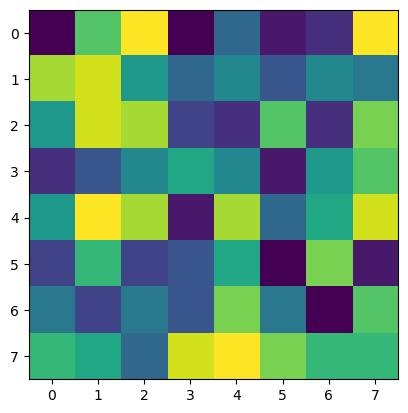

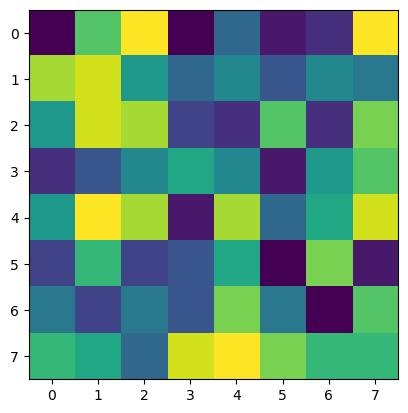

In [8]:
data = sample(qc_pcg)

plt.imshow(data.reshape((8, 8)))
plt.show()
plt.imshow(results.reshape((8, 8)))
plt.show()

In [9]:
print(np.sort(results))
print(results[:32])
results_cos = np.cos(2**(-4) * results[:32] * np.pi)
print(results_cos)
integral = np.sum(results_cos) / 32
integral

[ 0  0  0  0  1  1  1  1  2  2  2  2  3  3  3  3  4  4  4  4  5  5  5  5
  6  6  6  6  7  7  7  7  8  8  8  8  9  9  9  9 10 10 10 10 11 11 11 11
 12 12 12 12 13 13 13 13 14 14 14 14 15 15 15 15]
[ 0 11 15  0  5  1  2 15 13 14  8  5  7  4  7  6  8 14 13  3  2 11  2 12
  2  4  7  9  7  1  8 11]
[ 1.      -0.55557 -0.98079  1.       0.55557  0.98079  0.92388 -0.98079
 -0.83147 -0.92388  0.       0.55557  0.19509  0.70711  0.19509  0.38268
  0.      -0.92388 -0.83147  0.83147  0.92388 -0.55557  0.92388 -0.70711
  0.92388  0.70711  0.19509 -0.19509  0.19509  0.98079  0.      -0.55557]


0.12924313747813906

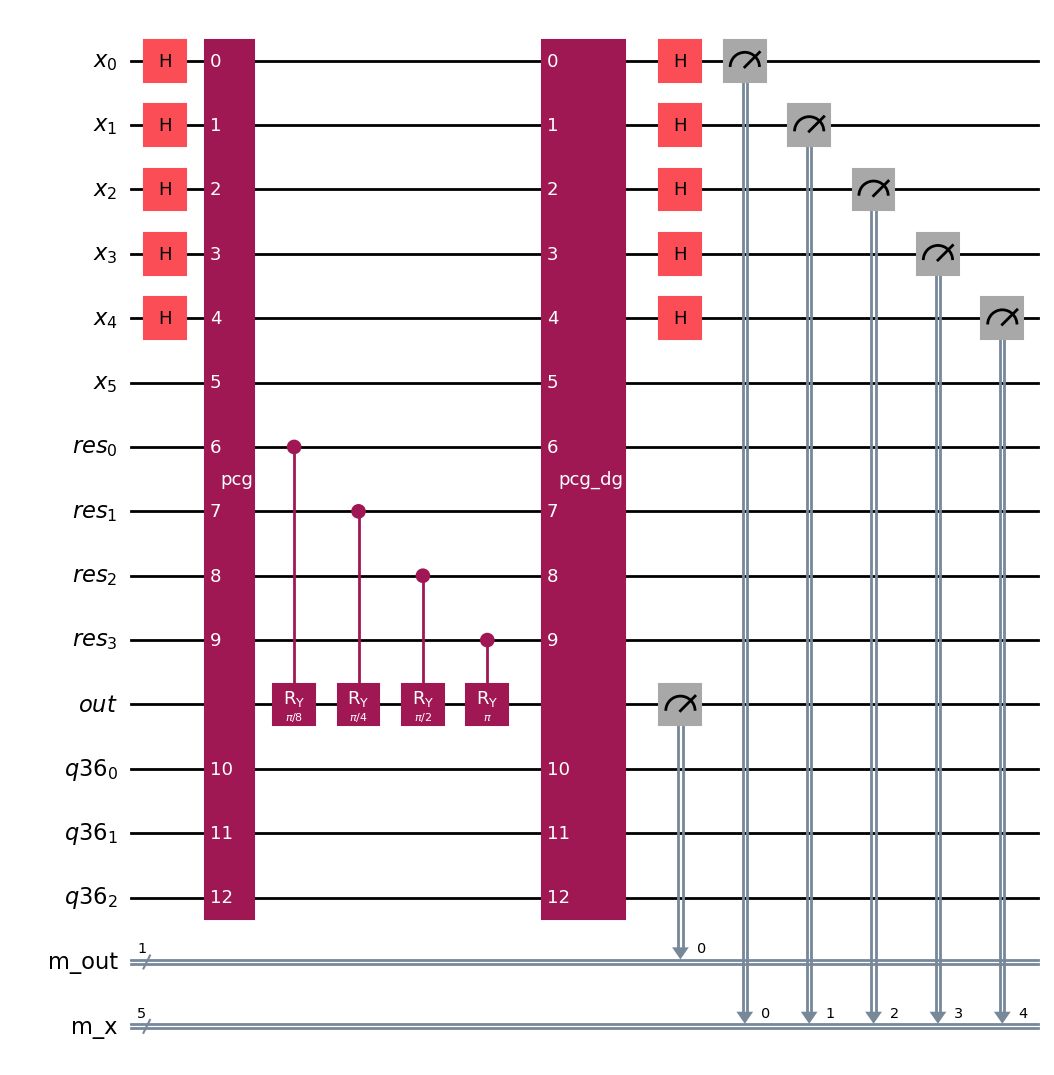

In [28]:
x = qk.QuantumRegister(6, "x")
res = qk.QuantumRegister(4, "res")
out = qk.QuantumRegister(1, "out")
rest = qk.QuantumRegister(qc_pcg.num_qubits - 6 - 4)

m_out = qk.ClassicalRegister(1, "m_out")
m_x = qk.ClassicalRegister(5, "m_x")

qc = qk.QuantumCircuit(x, res, out, rest, m_out, m_x)
qc.h(x[:5]) # 32 = 2 ** 5
qc.append(qc_pcg, x[:] + res[:] + rest[:])
for i in range(4):
    qc.cry(2 * 2**(i - 4) * np.pi, res[i], out)
qc.append(qc_pcg.inverse(), x[:] + res[:] + rest[:])
qc.h(x[:5])
qc.measure(out, m_out)
qc.measure(x[:5], m_x)
qc.draw(output="mpl")

In [29]:
shots = 10000
result = backend.run(qk.transpile(qc, backend), shots=shots).result()
counts = result.get_counts()
counts

{'11001 1': 1,
 '11011 1': 6,
 '00011 1': 5,
 '00101 1': 10,
 '01001 1': 10,
 '10111 1': 18,
 '00100 1': 8,
 '10010 1': 15,
 '11111 1': 83,
 '01101 1': 18,
 '01111 1': 4,
 '10011 1': 16,
 '10000 1': 39,
 '11000 1': 49,
 '00110 1': 3,
 '10000 0': 1,
 '00001 1': 21,
 '10011 0': 4,
 '01000 0': 9,
 '01100 0': 6,
 '00111 1': 33,
 '10110 0': 63,
 '10101 0': 25,
 '11110 0': 73,
 '10100 1': 26,
 '01110 1': 16,
 '11100 0': 178,
 '10101 1': 17,
 '11101 0': 56,
 '11010 0': 652,
 '00010 1': 13,
 '00010 0': 61,
 '01101 0': 425,
 '10010 0': 58,
 '00111 0': 1083,
 '01111 0': 378,
 '10001 0': 79,
 '01010 1': 191,
 '01000 1': 245,
 '11111 0': 112,
 '01001 0': 174,
 '01100 1': 2,
 '00000 0': 165,
 '11110 1': 1,
 '00110 0': 249,
 '00100 0': 176,
 '00000 1': 3884,
 '00011 0': 82,
 '01011 1': 3,
 '11101 1': 165,
 '10100 0': 90,
 '11011 0': 101,
 '00001 0': 72,
 '01011 0': 240,
 '11000 0': 156,
 '10111 0': 101,
 '00101 0': 229}

In [30]:
probability = counts["00000 0"] / shots
amplitude = np.sqrt(probability)
amplitude, integral, amplitude - integral

(0.1284523257866513, 0.12924313747813906, -0.0007908116914877583)

In [13]:
qk.transpile(qc, backend).count_ops()

OrderedDict([('cp', 180),
             ('ccx', 120),
             ('h', 64),
             ('mcphase', 50),
             ('cx', 10),
             ('cswap', 8),
             ('measure', 6),
             ('x', 4),
             ('cry', 4),
             ('u2', 2)])

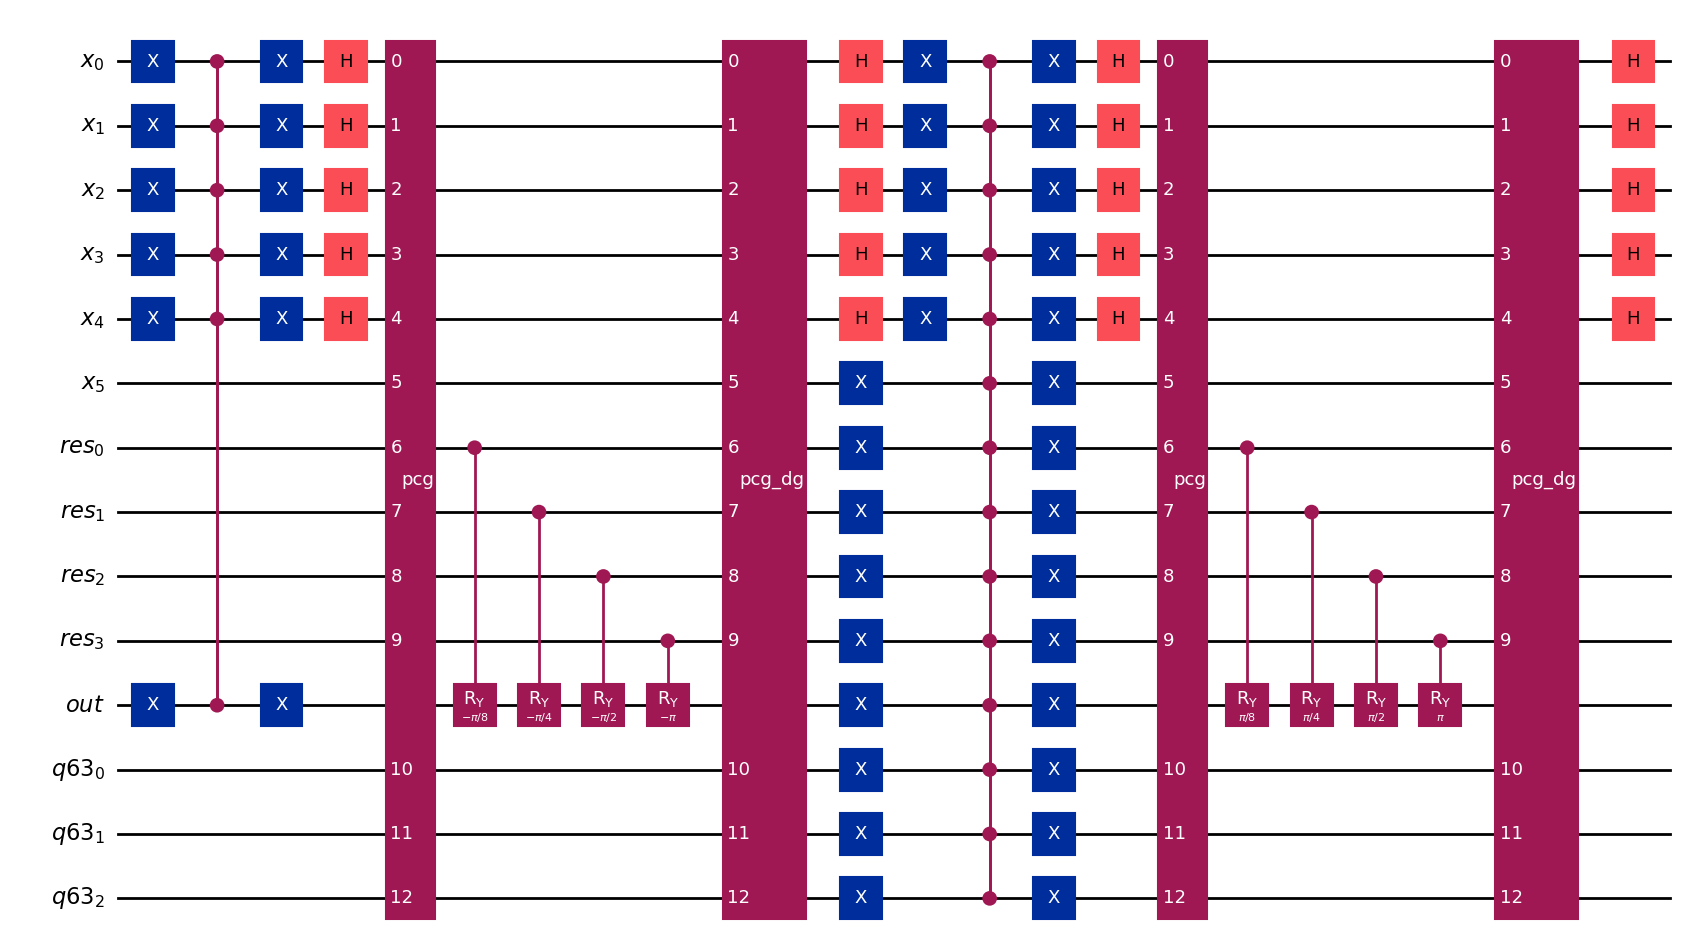

In [36]:
x = qk.QuantumRegister(6, "x") # 32 = 2 ** 5
res = qk.QuantumRegister(4, "res")
out = qk.QuantumRegister(1, "out")
rest = qk.QuantumRegister(qc_pcg.num_qubits - 6 - 4)

V = qk.QuantumCircuit(x, res, out, rest)
V.x(x[:5])
V.x(out)
V.append(ZGate().control(5), x[:5] + out[:])
V.x(x[:5])
V.x(out)
V.h(x[:5])
V.append(qc_pcg.to_gate(), x[:] + res[:] + rest[:])
for i in range(4):
    V.cry(-2 * 2**(i - 4) * np.pi, res[i], out)
V.append(qc_pcg.to_gate().inverse(), x[:] + res[:] + rest[:])
V.h(x[:5])
V.x(x[:] + res[:] + rest[:] + out[:])
V.append(ZGate().control(13), x[:] + rest[:] + res[:] + out[:])
V.x(x[:] + res[:] + rest[:] + out[:])
V.h(x[:5])
V.append(qc_pcg.to_gate(), x[:] + res[:] + rest[:])
for i in range(4):
    V.cry(2 * 2**(i - 4) * np.pi, res[i], out)
V.append(qc_pcg.to_gate().inverse(), x[:] + res[:] + rest[:])
V.h(x[:5])
V.append(GlobalPhaseGate(np.pi))

V.draw(output="mpl")

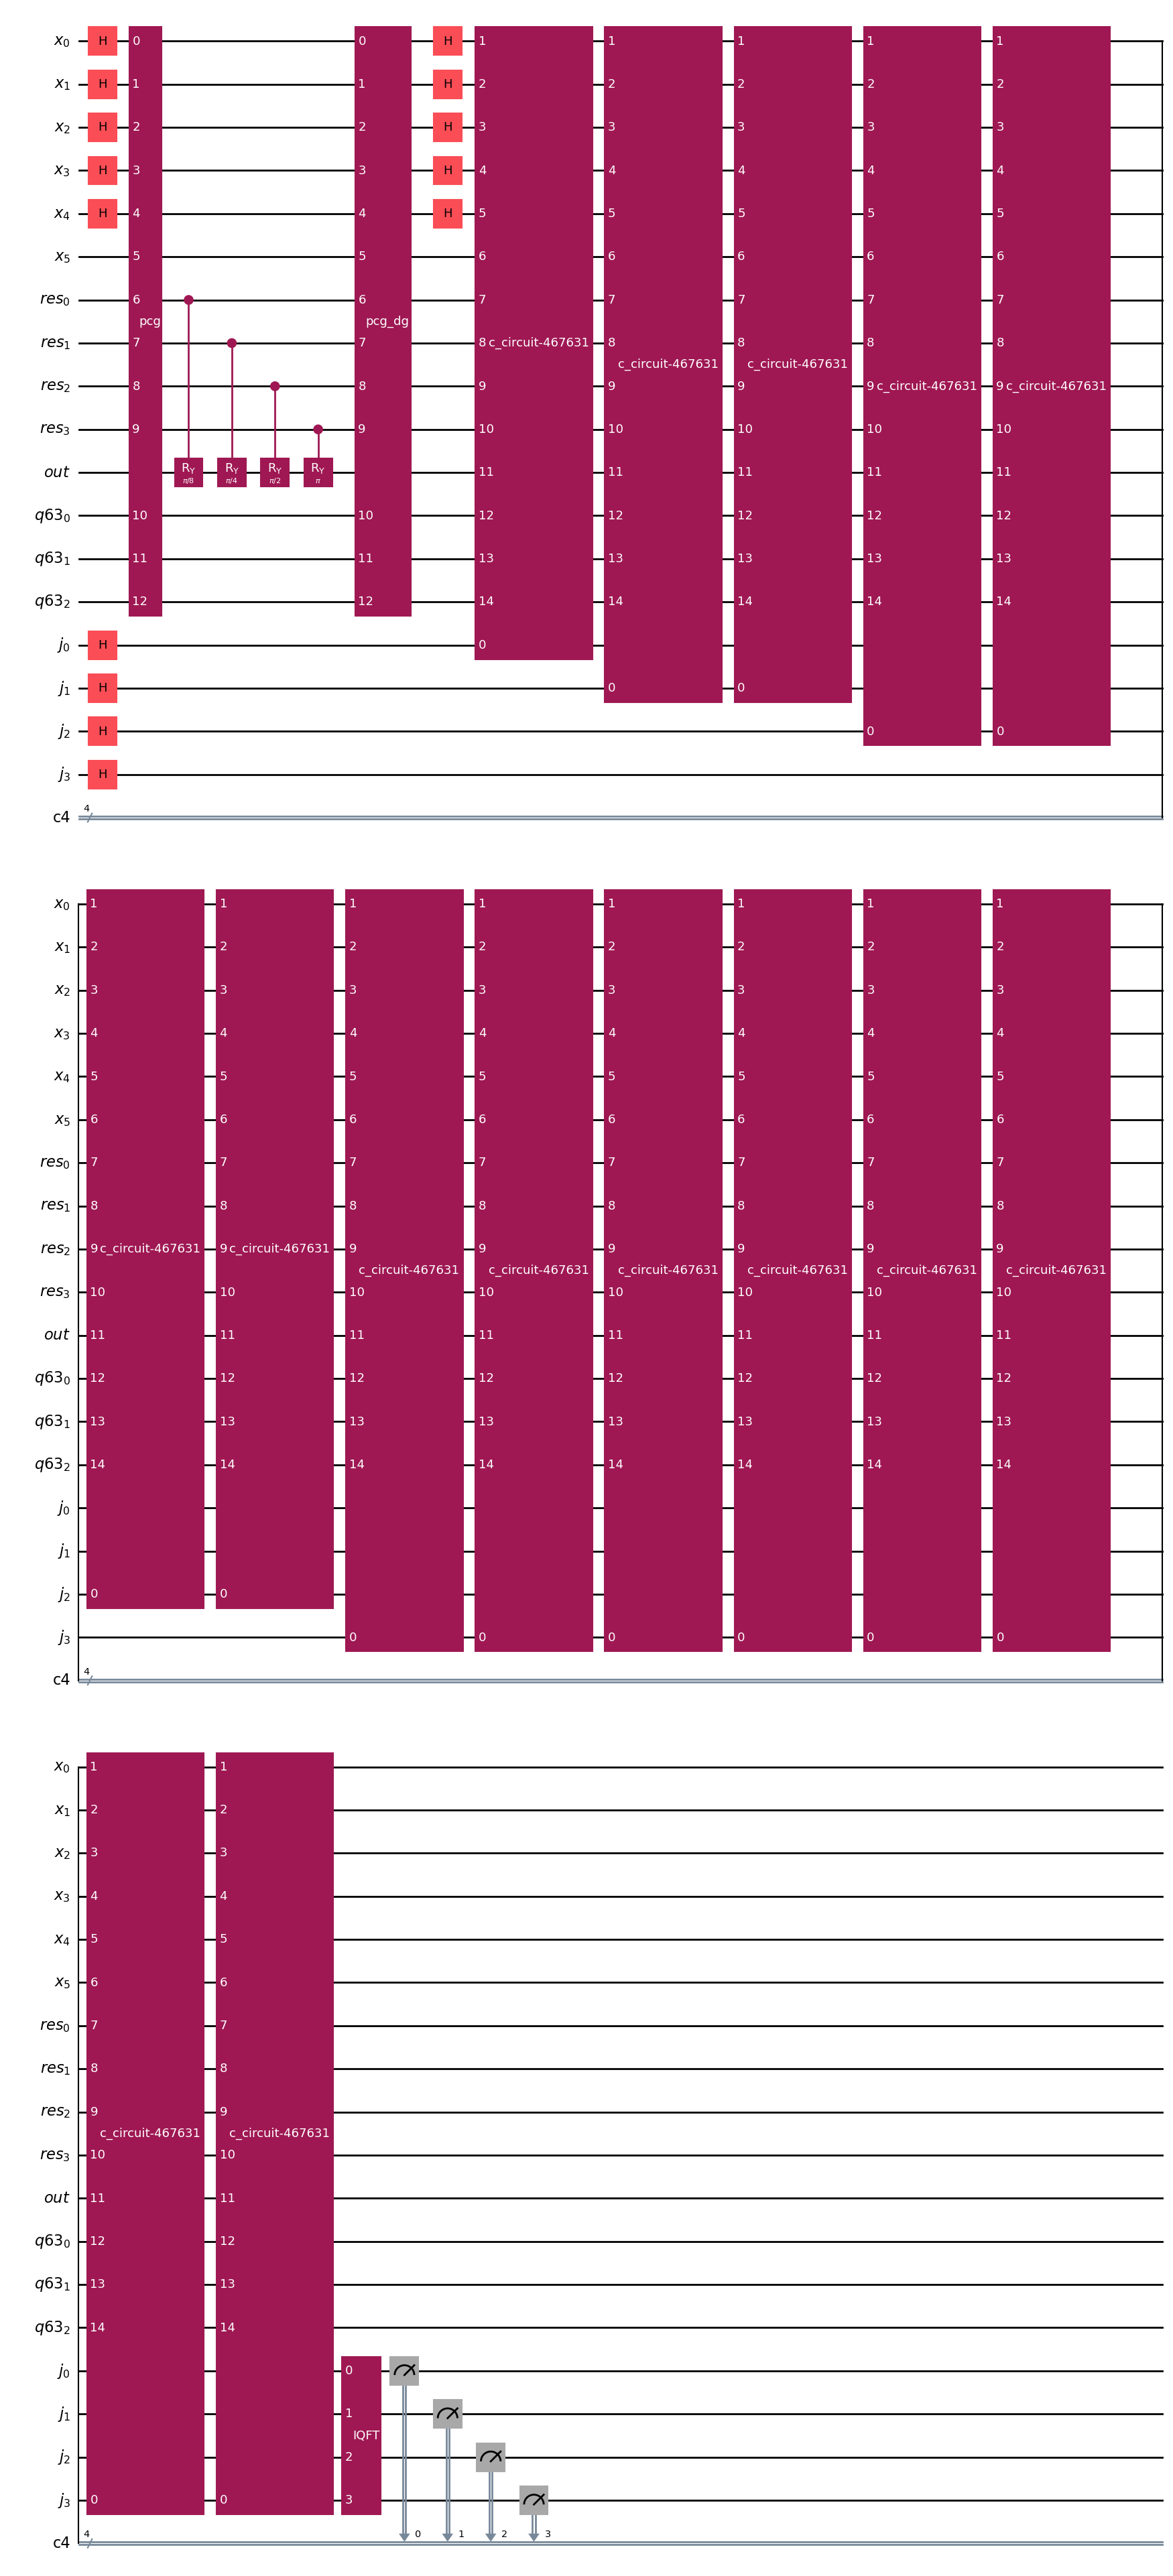

In [37]:
n = 4

j = qk.QuantumRegister(n, "j")
m_j = qk.ClassicalRegister(n)
U = qk.QuantumCircuit(x, res, out, rest, j, m_j)

U.h(x[:5])
U.append(qc_pcg.to_gate(), x[:] + res[:] + rest[:])
for i in range(4):
    U.cry(2 * 2**(i - 4) * np.pi, res[i], out)
U.append(qc_pcg.to_gate().inverse(), x[:] + res[:] + rest[:])
U.h(x[:5])

U.h(j)

for i in range(n):
    for _ in range(2**i):
        U.append(V.control(), [j[i]] + x[:] + res[:] + out[:] + rest[:])
U.append(QFT(4).inverse(), j)

U.measure(j, m_j)

U.draw(output="mpl")

In [42]:
result = backend.run(qk.transpile(U, backend), shots=10).result()
result.get_counts()

{'0000': 2, '0001': 4, '1111': 4}

In [41]:
np.sin(0b0001 * 2**(-n) * np.pi), np.sin(0b1111 * 2**(-n) * np.pi)

(0.19509032201612825, 0.1950903220161286)